# LAB 3 — Simple Linear Regression using Scikit-learn and OLS

### Part A: Data Collection and Preprocessing

In [7]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


Load the dataset using Pandas

In [8]:
df = pd.read_excel("M:\Machine Learning\Department Awareness Survey (Responses).xlsx")


<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\91639\AppData\Local\Temp\ipykernel_49848\4261082405.py:1: SyntaxWarning: invalid escape sequence '\M'
  df = pd.read_excel("M:\Machine Learning\Department Awareness Survey (Responses).xlsx")


Display first 5 rows

In [9]:
df.head()


,Timestamp,Registration Number,Email,Job role that you are interested in\n,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,2026-06-22 08:49:31.362,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,2026-06-22 08:49:50.520,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,2026-06-22 08:50:44.521,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,2026-06-22 08:51:00.666,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,2026-06-22 08:51:42.357,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


Check dataset dimensions

In [10]:
print("Shape:", df.shape)


Shape: (54, 15)


Identify missing values

In [11]:
print("Null values:")
print(df.isnull().sum())


Null values:
Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in\n                                                         0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the  median salary of students placed through campus (In LPA..respond as a number)    0
Which is the highest paying company                                                           0
Rate your contribution towards extra curricular activities                                    0
Rate your technical competencies                                                              0
What are your package expec

Convert required columns to numeric and handle inconsistent entries

> **Note on data issues found in this dataset:**
> Some students entered CIA % as a proportion (e.g. `0.70` instead of `70`) — these are multiplied by 100.
> Some entered non-numeric values like `'-'` or `'na'` — these are converted to NaN and dropped.
> GPA values above 4.0 (like `90`, `10`, `7.8`) are impossible on a 4-point scale and are dropped.
> Attendance values like `'Option 1'` (Google Form glitch) are also dropped.

In [12]:
# CIA %
cia = pd.to_numeric(df['your CIA % of last semester '], errors='coerce')
cia = cia.apply(lambda x: x * 100 if pd.notna(x) and x < 2 else x)
df['your CIA % of last semester '] = cia.where((cia >= 10) & (cia <= 100))

# GPA — valid range 0 to 4 (4-point scale)
df['your GPA of last semester'] = pd.to_numeric(
    df['your GPA of last semester'], errors='coerce'
)
df = df[
    (df['your GPA of last semester'] >= 0) &
    (df['your GPA of last semester'] <= 4)
]

# Attendance %
att = pd.to_numeric(df['Your maximum attendance % till last semester'], errors='coerce')
att = att.apply(lambda x: x * 100 if pd.notna(x) and x < 2 else x)
df['Your maximum attendance % till last semester'] = att.where((att >= 50) & (att <= 100))

# Drop nulls and duplicates
df.dropna(subset=['your CIA % of last semester ',
                   'your GPA of last semester',
                   'Your maximum attendance % till last semester'], inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print("Rows after cleaning:", len(df))


Rows after cleaning: 42


Statistical summary

In [13]:
print(df[['your CIA % of last semester ',
          'your GPA of last semester',
          'Your maximum attendance % till last semester']].describe())


       your CIA % of last semester   your GPA of last semester  \
count                     42.000000                  42.000000   
mean                      73.236429                   3.497619   
std                        6.036706                   0.246426   
min                       60.000000                   2.900000   
25%                       70.000000                   3.400000   
50%                       71.000000                   3.500000   
75%                       78.000000                   3.630000   
max                       89.000000                   4.000000   

       Your maximum attendance % till last semester  
count                                     42.000000  
mean                                      93.686429  
std                                        4.461239  
min                                       85.000000  
25%                                       90.000000  
50%                                       94.625000  
75%                        

---
## Experiment 1 — CIA % predicts GPA

Select independent and dependent variables

In [14]:
X = df[['your CIA % of last semester ']]
y = df['your GPA of last semester']


Simple Linear Regression using Scikit-learn

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

slope = model.coef_[0]
intercept = model.intercept_

print("Slope =", slope)
print("Intercept =", intercept)

y_pred = model.predict(X_test)
print("Predicted Values:")
print(y_pred)


Slope = 0.019091285054412023
Intercept = 2.088885510753385
Predicted Values:
[3.52073189 3.61618832 3.32351892 3.44436675 3.67346217 3.53982317
 3.57800574 3.42527546 3.42527546]


Comparison between actual and predicted

In [16]:
comparison_df = pd.DataFrame({
    'Actual GPA': y_test.values,
    'Predicted GPA': y_pred
})
print(comparison_df.head())


   Actual GPA  Predicted GPA
0        3.60       3.520732
1        3.60       3.616188
2        3.40       3.323519
3        3.40       3.444367
4        3.89       3.673462


Manual OLS Computation

In [17]:
x = df['your CIA % of last semester ']
y_manual = df['your GPA of last semester']

x_mean = np.mean(x)
y_mean = np.mean(y_manual)

m = np.sum((x - x_mean) * (y_manual - y_mean)) / np.sum((x - x_mean) ** 2)
b = y_mean - (m * x_mean)

print("Manual Slope =", m)
print("Manual Intercept =", b)
print("Regression Equation:")
print("ŷ =", m, "* x +", b)

manual_predictions = m * X_test.squeeze() + b
print(manual_predictions.head())


Manual Slope = 0.019157930416686023
Manual Intercept = 2.094560645081023
Regression Equation:
ŷ = 0.019157930416686023 * x + 2.094560645081023
25    3.531405
13    3.627195
8     3.333504
26    3.454774
4     3.684669
Name: your CIA % of last semester , dtype: float64


Comparison between Scikit-learn and Manual OLS

In [18]:
comparison = pd.DataFrame({
    'Scikit Prediction': y_pred,
    'Manual OLS Prediction': manual_predictions.values
})
comparison['Difference'] = abs(
    comparison['Scikit Prediction'] - comparison['Manual OLS Prediction']
)
print(comparison.head())


   Scikit Prediction  Manual OLS Prediction  Difference
0           3.520732               3.531405    0.010674
1           3.616188               3.627195    0.011007
2           3.323519               3.333504    0.009985
3           3.444367               3.454774    0.010407
4           3.673462               3.684669    0.011207


The predictions from Scikit-learn and manual OLS are nearly identical.
The small differences are due to floating-point precision only.
Both methods produce the same regression line.

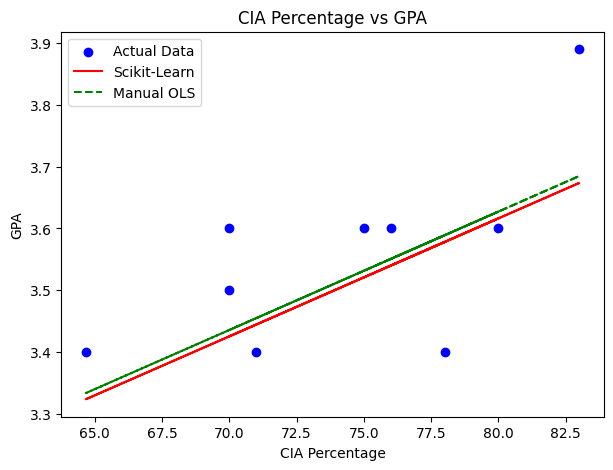

In [19]:
plt.figure(figsize=(7, 5))
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test, y_pred, color='red', label='Scikit-Learn')
plt.plot(X_test, manual_predictions, color='green', linestyle='--', label='Manual OLS')
plt.xlabel('CIA Percentage')
plt.ylabel('GPA')
plt.title('CIA Percentage vs GPA')
plt.legend()
plt.show()


## Parameter Saving Task

Save Parameters using Pickle

In [20]:
parameters = {
    'slope': slope,
    'intercept': intercept
}

with open('linear_regression_weights.pkl', 'wb') as file:
    pickle.dump(parameters, file)

print("Parameters saved successfully.")


Parameters saved successfully.


Load Pickle File

In [21]:
with open('linear_regression_weights.pkl', 'rb') as file:
    loaded_parameters = pickle.load(file)

print(loaded_parameters)


{'slope': np.float64(0.019091285054412023), 'intercept': np.float64(2.088885510753385)}


Prediction using Loaded Parameters

In [22]:
new_cia = 80

predicted_gpa = (
    loaded_parameters['slope'] * new_cia
    + loaded_parameters['intercept']
)

print("Predicted GPA =", predicted_gpa)


Predicted GPA = 3.6161883151063465


---
## Experiment 2 — Attendance % predicts GPA

Select independent and dependent variables

In [23]:
X = df[['Your maximum attendance % till last semester']]
y = df['your GPA of last semester']


Simple Linear Regression using Scikit-learn

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

slope = model.coef_[0]
intercept = model.intercept_

print("Slope =", slope)
print("Intercept =", intercept)

y_pred = model.predict(X_test)
print("y_pred =", y_pred)


Slope = 0.021879948852717795
Intercept = 1.4352718878120556
y_pred = [3.49198708 3.47010713 3.51386703 3.40446728 3.57950688 3.59504164
 3.62326677 3.33882744 3.44822718]


Manual OLS Computation

In [25]:
x = df['Your maximum attendance % till last semester']
y_manual = df['your GPA of last semester']

x_mean = np.mean(x)
y_mean = np.mean(y_manual)

m = np.sum((x - x_mean) * (y_manual - y_mean)) / np.sum((x - x_mean) ** 2)
b = y_mean - (m * x_mean)

print("Manual Slope =", m)
print("Manual Intercept =", b)
print("ŷ =", m, "* x +", b)

manual_predictions = m * X_test.squeeze() + b


Manual Slope = 0.019959151874305414
Manual Intercept = 1.6277173912006389
ŷ = 0.019959151874305414 * x + 1.6277173912006389


Comparison

In [26]:
comparison = pd.DataFrame({
    'Scikit Prediction': y_pred,
    'Manual OLS Prediction': manual_predictions.values
})
comparison['Difference'] = abs(
    comparison['Scikit Prediction'] - comparison['Manual OLS Prediction']
)
print(comparison.head())


   Scikit Prediction  Manual OLS Prediction  Difference
0           3.491987               3.503878    0.011891
1           3.470107               3.483919    0.013811
2           3.513867               3.523837    0.009970
3           3.404467               3.424041    0.019574
4           3.579507               3.583714    0.004207


The manual implementation of linear regression produced predictions that closely match
those from Scikit-learn. The small differences are negligible, confirming the regression
equation was calculated correctly.

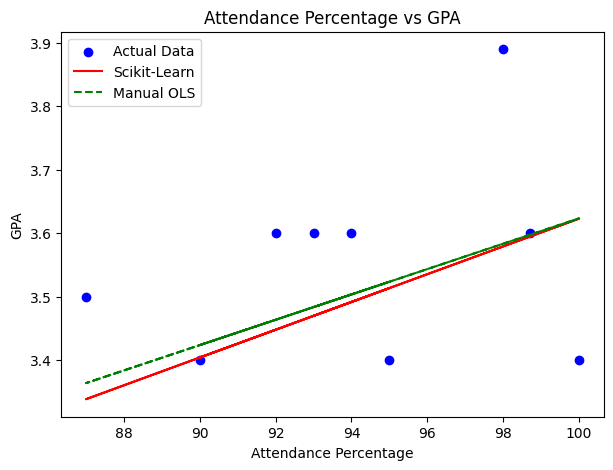

In [27]:
plt.figure(figsize=(7, 5))
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test, y_pred, color='red', label='Scikit-Learn')
plt.plot(X_test, manual_predictions, color='green', linestyle='--', label='Manual OLS')
plt.xlabel('Attendance Percentage')
plt.ylabel('GPA')
plt.title('Attendance Percentage vs GPA')
plt.legend()
plt.show()


Save Parameters using Pickle

In [28]:
parameters = {
    'slope': slope,
    'intercept': intercept
}

with open('linear_regression_weights_attendance.pkl', 'wb') as file:
    pickle.dump(parameters, file)

print("Parameters saved successfully.")


Parameters saved successfully.


## Final Observations and Inference

In this lab, I first preprocessed the survey dataset by converting columns to numeric format,
fixing inconsistent entries (proportions entered instead of percentages, invalid GPA values above 4.0),
removing missing values, and dropping duplicate records.

After cleaning, I performed Simple Linear Regression using both Scikit-learn and the manual
Ordinary Least Squares (OLS) method for two experiments.

For both experiments, the predictions from Scikit-learn and Manual OLS were almost identical,
with only negligible floating-point differences. This confirmed the correctness of the manually
calculated regression equation.

I also saved the learned model parameters (slope and intercept) using Pickle and successfully
loaded them for making new predictions.

From the analysis, both **CIA Percentage** and **Attendance Percentage** show a positive
relationship with **GPA** and can be used as predictor variables in Simple Linear Regression.
